# Applied Machine Learning Project
## Gene Foxwell

### Description: This project looks at building a Machine Learning Model to predict if a star has an exoplanet orbiting around it based on observations changes in the stars light intensity (flux) over time.

### Dataset: https://www.kaggle.com/datasets/keplersmachines/kepler-labelled-time-series-data/data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from scipy.fft import rfft
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import kagglehub

C:\Users\genef\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


## Step 1: Load Dataset

The dataset comes in two parts - a test set and training set. We'll load the training set here and use it to build a reproducible pipeline before using the test set to evaluate the final results.

In [2]:
path = kagglehub.dataset_download("keplersmachines/kepler-labelled-time-series-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\genef\.cache\kagglehub\datasets\keplersmachines\kepler-labelled-time-series-data\versions\3


In [3]:
df_train = pd.read_csv(f"{path}/exoTrain.csv")
df_train.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


## Step 2: Describing the Dataset

### Background Information

This dataset is intended to build a model for predicting if a star has a planet around it based on observations of its light intensity. The general idea is that if a planet passes between the star and Earth, then the light intensity will be dimmed compared to other observations, indicating a possible planet in orbit around that star.

So our machine learning model needs to look for periods of "dimness" compared to other observations.

### Dataset Description

* **LABEL:** Either 1 -> No planet is around this star; or 2 -> There is a high probability of a planet around this star.
* **FLUX.N:** These are the series of observations made of the stars light intensity. We will assume that these measurements were taken at roughly equivalent intervals.

We have 5087 rows of data.
Each row has a Label and 3197 Flux Readings for the corresponding stars.

In [4]:
df_train.describe()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
count,5087.000000,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,...,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5087.000000,5087.000000,5087.000000,5087.000000
mean,1.007273,1.445054e+02,1.285778e+02,1.471348e+02,1.561512e+02,1.561477e+02,1.469646e+02,1.168380e+02,1.144983e+02,1.228639e+02,...,3.485578e+02,4.956476e+02,6.711211e+02,7.468790e+02,6.937372e+02,6.553031e+02,-494.784966,-544.594264,-440.239100,-300.536399
std,0.084982,2.150669e+04,2.179717e+04,2.191309e+04,2.223366e+04,2.308448e+04,2.410567e+04,2.414109e+04,2.290691e+04,2.102681e+04,...,2.864786e+04,3.551876e+04,4.349963e+04,4.981375e+04,5.087103e+04,5.339979e+04,17844.469520,17722.339334,16273.406292,14459.795577
min,1.000000,-2.278563e+05,-3.154408e+05,-2.840018e+05,-2.340069e+05,-4.231956e+05,-5.975521e+05,-6.724046e+05,-5.790136e+05,-3.973882e+05,...,-3.240480e+05,-3.045540e+05,-2.933140e+05,-2.838420e+05,-3.288214e+05,-5.028894e+05,-775322.000000,-732006.000000,-700992.000000,-643170.000000
25%,1.000000,-4.234000e+01,-3.952000e+01,-3.850500e+01,-3.505000e+01,-3.195500e+01,-3.338000e+01,-2.813000e+01,-2.784000e+01,-2.683500e+01,...,-1.760000e+01,-1.948500e+01,-1.757000e+01,-2.076000e+01,-2.226000e+01,-2.440500e+01,-26.760000,-24.065000,-21.135000,-19.820000
50%,1.000000,-7.100000e-01,-8.900000e-01,-7.400000e-01,-4.000000e-01,-6.100000e-01,-1.030000e+00,-8.700000e-01,-6.600000e-01,-5.600000e-01,...,2.600000e+00,2.680000e+00,3.050000e+00,3.590000e+00,3.230000e+00,3.500000e+00,-0.680000,0.360000,0.900000,1.430000
75%,1.000000,4.825500e+01,4.428500e+01,4.232500e+01,3.976500e+01,3.975000e+01,3.514000e+01,3.406000e+01,3.170000e+01,3.045500e+01,...,2.211000e+01,2.235000e+01,2.639500e+01,2.909000e+01,2.780000e+01,3.085500e+01,18.175000,18.770000,19.465000,20.280000
max,2.000000,1.439240e+06,1.453319e+06,1.468429e+06,1.495750e+06,1.510937e+06,1.508152e+06,1.465743e+06,1.416827e+06,1.342888e+06,...,1.779338e+06,2.379227e+06,2.992070e+06,3.434973e+06,3.481220e+06,3.616292e+06,288607.500000,215972.000000,207590.000000,211302.000000


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5087 entries, 0 to 5086
Columns: 3198 entries, LABEL to FLUX.3197
dtypes: float64(3197), int64(1)
memory usage: 124.1 MB


In [6]:
df_train.isnull().sum().sum()

np.int64(0)

In [7]:
df_train["LABEL"].value_counts()

LABEL
1    5050
2      37
Name: count, dtype: int64

So our dataset is quite sparse on positive planet identifications - we have 5050 rows that do not correspond with a planet, and 37 that do.

We have no missing values.

## Step 3 Exploratory Data Analysis

Let's start by getting a look at what the individual time series actually look like for each of the two groups.

In [8]:
def plot_flux_samples(df, n_samples=3, categories = [
        (2, 'green', 'Planet (Label 2)'),
        (1, 'black', 'No Planet (Label 1)')
    ], file_name="images/fluxintensity_chart.png"):
    """
    Plots a line graph of the flux observations for n_samples stars with low probability of a planet and n_samples stars with a high probability of a planets.
    Standardizes the inputs so they can be easily compared on the graph.

    args:
        df: The source dataframe.
        n_samples: The number of samples for each class.
        categories: The categories of data to show.
        file_name: The file name to save the chart under
    Returns:
        None; simply renders the appropriate chart.
    """
    plt.figure(figsize=(15, 8))
    
    
    for label, color, label_name in categories:
        samples = df[df['LABEL'] == label].sample(n_samples, random_state=42)
        
        for i in range(n_samples):
            flux = samples.iloc[i, 1:]
            
            flux_standardized = (flux - flux.mean()) / flux.std()
            
            plt.plot(flux_standardized, color=color, alpha=0.2, 
                     label=label_name if i == 0 else "")
    
    plt.title("Standardized Flux Intensity: Planet (Green) vs No Planet (Black)")
    plt.xlabel("Observation Point (Time)")
    plt.ylabel("Standardized Flux")

    plt.xticks([]) 

    plt.legend()
    plt.savefig(file_name);


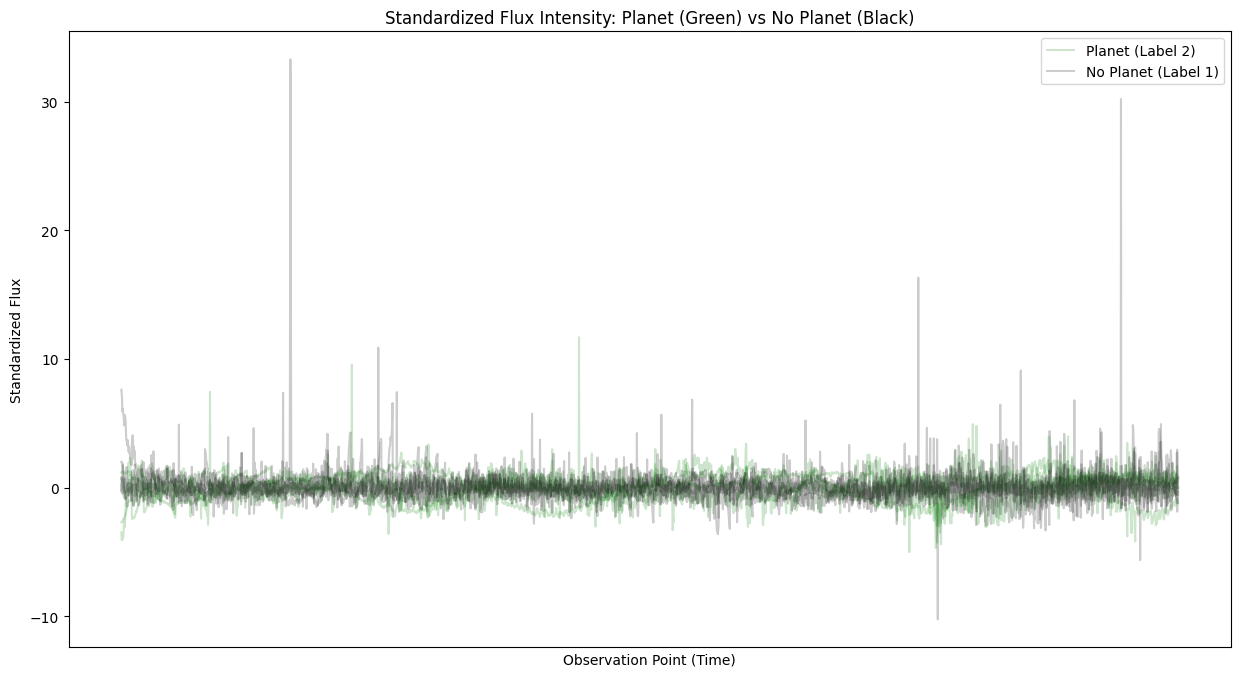

In [9]:
# Run the plot with both datasets
plot_flux_samples(df_train, 4)

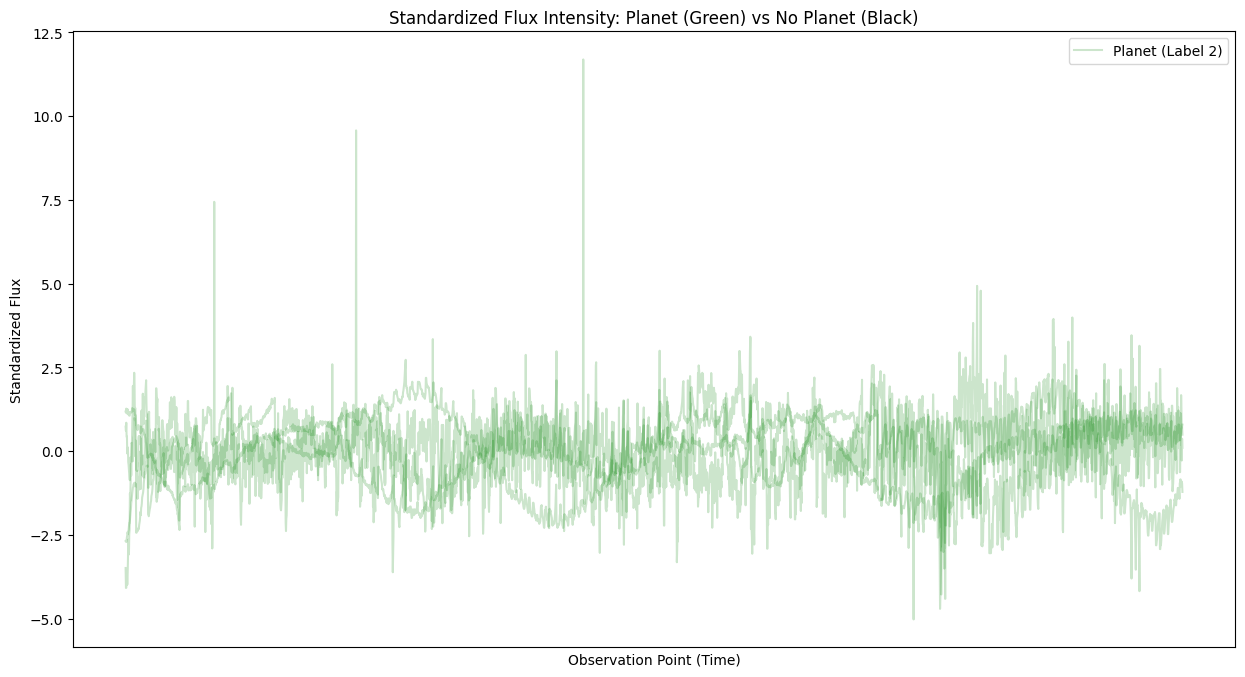

In [10]:
# render the plot with only positive data
plot_flux_samples(df_train, 4, categories = [(2, 'green', 'Planet (Label 2)')], file_name="images/planets_only.png")

A few observations about the data:

* It is very noisy. This is perhaps expected given the difficultly of observing starlight from hundreds of thousands or even millions of lightyears away.
* As expected, the flux data for stars that have planets tend to have prolonged "dips" in their light intensity (corresponding to the possible transit of a planet across the star)

## Step 4: Data Preprocessing Pipeline

Our Preprocessing Pipeline will consist of two steps:

* Data Standardization: As we did during EDA we will standardize the data.
* Data Binning: To smooth out the data, and reduce the dimensionality, we'll bin the data according to its mean.

First, lets splits up the features and labels.  

In [11]:
def split_labels_features(df):
    """
    Pulls out the features and the training/test labels. Maps the labels onto 0/1 in order to make the data easier
    for an ML algorithm to consume.

    Args:
        df: Source dataframe.
    Returns:
        X: Feature rows.
        y: Label vector
    """
    X = df.drop("LABEL", axis=1)
    y = df["LABEL"].map({1:0, 2:1})

    return X, y

In [12]:
X_train, y_train = split_labels_features(df=df_train)

Now we define a Transformer that transforms our data into bins

In [ ]:
class BinnedZScoreTransformer(BaseEstimator, TransformerMixin):
    """
    This transformer divides the data into bins, each of size bin_size. For each bin-size the system returns the Z-Score. The Z-Score is the number of standard deviations
    a value is above or below the mean of the row.
    """
    def __init__(self, bin_size=32):
        self.bin_size = bin_size
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X_arr = np.array(X)
        n_samples, n_features = X_arr.shape
        n_bins = n_features // self.bin_size
        
        row_means = X_arr.mean(axis=1, keepdims=True)
        row_stds = X_arr.std(axis=1, keepdims=True)
        
        X_binned = X_arr[:, :n_bins * self.bin_size].reshape(n_samples, n_bins, self.bin_size)
        window_means = X_binned.mean(axis=2)
        
        z_scores = (window_means - row_means) / (row_stds + 1e-8)
        
        return z_scores


In [ ]:
def prepare_fft_features(X):
    """
    applies the rfft algorithm and returns the absolute value of each entry.
    """
    return np.abs(rfft(X, axis=1))

Now we'll build the preprocessing pipeline...

In [15]:
observations_pipeline = Pipeline([
    ("fft", FunctionTransformer(prepare_fft_features)),
    ("binning", BinnedZScoreTransformer(bin_size=16)),
    ("scaler", StandardScaler())
])

In [16]:
observations_pipeline

,steps,"[('fft', ...), ('binning', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function pre...00166676065C0>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


As a santiy check for our pipeline, we'll plot the resulting data...

In [17]:
observations_pipeline.fit(X_train)
X_train_transformed = observations_pipeline.transform(X_train)

In [ ]:

def plot_clipped_zscores_bar(X_transformed, y, n_samples=3, file_name="images/transformed_data.png"):
    """
    Plots the binned Z-Scores as a bar chart where all non-dips have been clipped to zero.

    Args:
        X_transformed: The transformed flux measurements.
        y: The true predictions for dataset.
        n_samples: How many samples from each category to plot.
        file_name: The filename to save the plot to.
    """
    X_transformed = np.array(X_transformed)
    y = np.array(y).flatten()
    
    fig, ax = plt.subplots(figsize=(15, 7))
    
    categories = [
        (1, 'green', 'Planet (Label 1)'),
        (0, 'black', 'No Planet (Label 0)')
    ]
    
    x_indices = np.arange(X_transformed.shape[1])
    
    for label_val, color, label_name in categories:
        label_indices = np.where(y == label_val)[0]
        
   
        if len(label_indices) > 0:
            selected_indices = np.random.choice(
                label_indices, 
                min(n_samples, len(label_indices)), 
                replace=False
            )
            
            for i, idx in enumerate(selected_indices):
                ax.bar(x_indices, X_transformed[idx], color=color, alpha=0.4, 
                       label=label_name if i == 0 else "")
    
    ax.set_title("Binned Z-Scores (Bar Chart)")
    ax.set_xlabel("Binned Observation Index")
    ax.set_ylabel("Z-Score")
    
    ax.set_ylim(bottom=None, top=1.0) 
    
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.savefig(file_name)

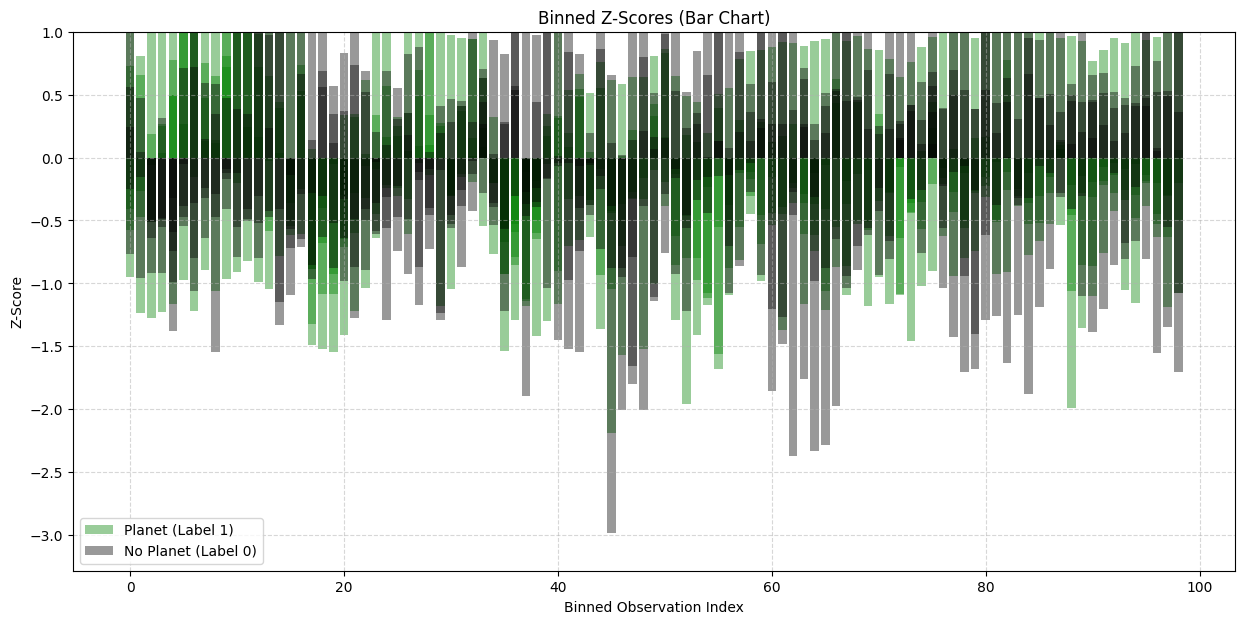

In [19]:
plot_clipped_zscores_bar(X_train_transformed, y_train, n_samples=5)

## Step 5: Model Training

First, let's load and process the test dataset (provided by Kaggle)

In [20]:
df_test = pd.read_csv(f"{path}/exoTest.csv")

X_test, y_test = split_labels_features(df_test)

Let's define a function for testing our classifiers results.

In [ ]:
def plot_model_results(model_name, y_true, y_pred, file_name):
    """
    Plots a dual confusion matrix: one with raw counts and one normalized by row (Recall).

    Args:
        model_name: The name of the model to display in the results.
        y_true: The true predictions from the dataset.
        y_pred: The predictions from the model.
        file_name: The file name to save the resulting confusion matrix to.
    """

    print(f"{model_name} F1 Score: {f1_score(y_pred=y_pred, y_true=y_true)}")
    print(f"{model_name} Accuracy Score: {accuracy_score(y_pred=y_pred, y_true=y_true)}")
    print(f"{model_name} Precision Score: {precision_score(y_pred=y_pred, y_true=y_true)}")
    print(f"{model_name} Recall Score: {recall_score(y_pred=y_pred, y_true=y_true)}")

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Raw Counts Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Planet', 'Planet'])
    disp.plot(ax=ax[0], cmap='Blues', values_format='d')
    ax[0].set_title('Confusion Matrix (Raw Counts)')
    
    # 2. Normalized Matrix (Shows Recall for each class)
    # This is critical for seeing how many of the 37 planets you actually caught!
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['No Planet', 'Planet'])
    disp_norm.plot(ax=ax[1], cmap='Greens', values_format='.2f')
    ax[1].set_title('Normalized Confusion Matrix (Recall)')
    
    plt.tight_layout()
    plt.savefig(file_name)

Our dataset is *extremely unbalanced* towards stars not having a planet. This makes it difficult for models to property learn the data. To fix this, we will create a new training set that is balanced.

In [22]:
planets = df_train[df_train['LABEL'] == 2]
non_planets = df_train[df_train['LABEL'] == 1]

# Oversample the minority class (planets) to match the majority class (non-planets)
planets_oversampled = planets.sample(n=len(non_planets), replace=True, random_state=42)

balanced_df = pd.concat([planets_oversampled, non_planets])
X_train_balanced = balanced_df.drop('LABEL', axis=1)
y_train_balanced = balanced_df['LABEL'].map({1: 0, 2: 1})

In [23]:
X_train_transformed = observations_pipeline.fit_transform(X_train_balanced)

In [24]:
clf = SVC(kernel='rbf', C=0.05)
clf.fit(X_train_transformed, y_train_balanced)


,C,0.05
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [25]:
X_test_transformed = observations_pipeline.transform(X_test)
y_pred = clf.predict(X_test_transformed)

Planet:  F1 Score: 0.5263157894736842
Planet:  Accuracy Score: 0.9842105263157894
Planet:  Precision Score: 0.35714285714285715
Planet:  Recall Score: 1.0


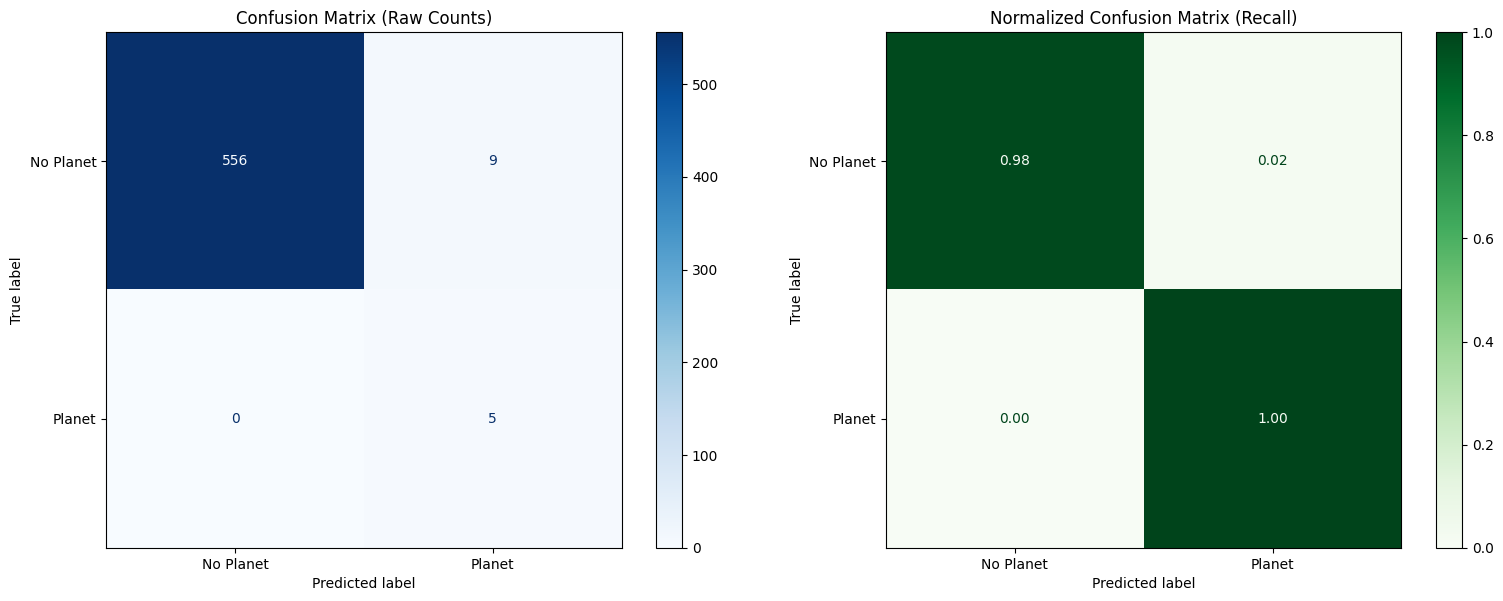

In [26]:
plot_model_results("Planet: ", y_test, y_pred, "images/confusion_matrix_pregrid.png")

## Step 6: Model Fine-Tuning ( Grid Search CV )

In [29]:
X_train_data = observations_pipeline.transform(X_train)

param_grid = {
    'C': [1, 0.1, 0.05, 0.005, 0.001, 0.0001],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001, 'scale'],
    'class_weight': ['balanced'] 
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


grid = GridSearchCV(
    SVC(kernel='rbf'), 
    param_grid, 
    cv=cv_strategy, 
    scoring='precision', 
    verbose=2, 
    n_jobs=-1 # Uses all CPU cores
)

grid.fit(X_train_data, y_train)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best F1 Score: {grid.best_score_:.4f}")


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 0.01}
Best F1 Score: 0.3516


Planet:  F1 Score: 0.7272727272727273
Planet:  Accuracy Score: 0.9947368421052631
Planet:  Precision Score: 0.6666666666666666
Planet:  Recall Score: 0.8


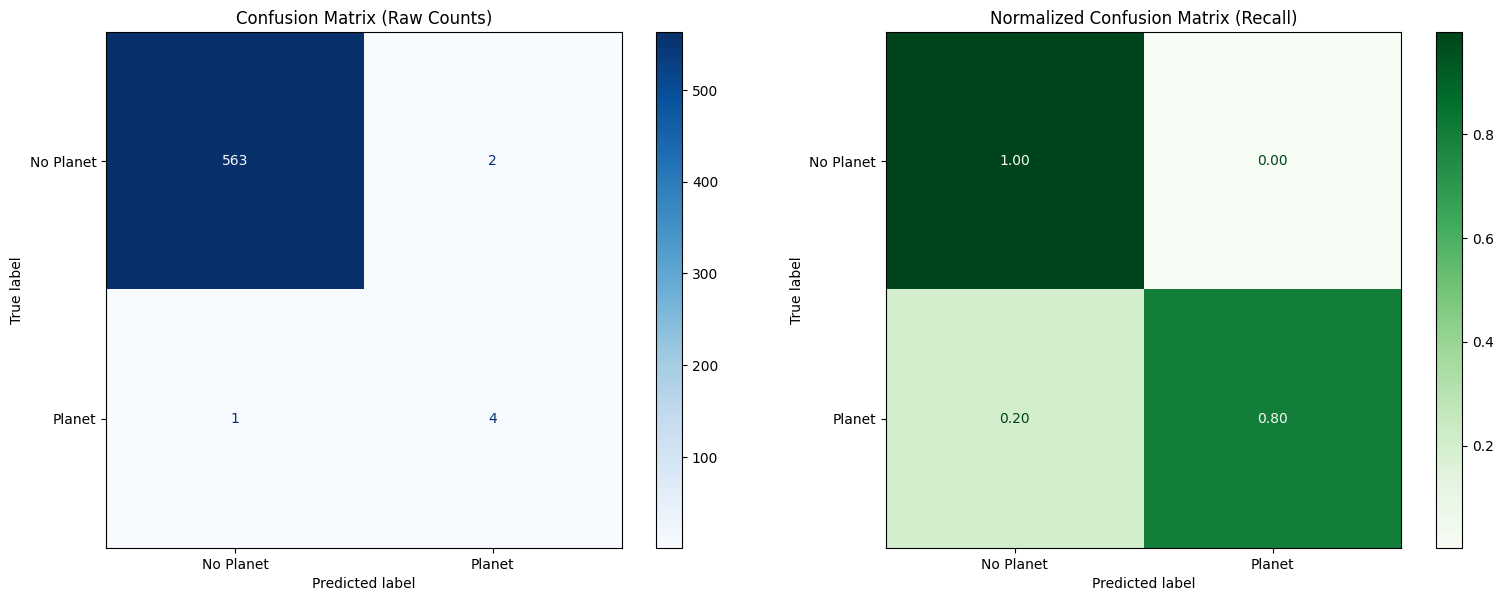

In [28]:
y_pred = grid.best_estimator_.predict(X_test_transformed)
plot_model_results("Planet: ", y_test, y_pred, "images/confusion_matrix_postgrid.png")

## Summary of Results

We trained a Support Vector Machine to find potential exoplanets based on flux measurements taken from the Keppler Telescope. This dataset was extremely imbalanced, with only 37 out 5087 rows of training data having a positive match, with only 5 examples of the 500ish test rows having a positive match.

We did the following transformations to clean up the data:

* Fast Fourier Transform to remove high frequency noise in the data.
* Binned the data using the z-score to reduce dimensionality and pull out possible planetary transits accross the star.
* Standardardized the data.

We trained an SVC using oversampled data to ensure it would work.

We then fine tuned the approach using GridSearchCV.

In the end our results are best summed by the final confusion matrix:

* The system correctly identified 4 out of 5 stars with an Exoplanet.
* The system correctly identified all but 2 of the stars without an Exoplanet.

The following metrics were obtained from the final model:

* F1 Score: 0.72
* Accuracy Score: 0.994
* Precision Score: 0.67
* Recall Score: 0.8

It is interesting to note that while the optimized model has higher F1, Accuracy, and Precision, it scored lower on Recall Score. It seems that the GridSearchCV optimized version of the SVM traded a slight dip in identifying stars with planets (identifying one fewer planet) in return for fewer false positives. (False positives were reduced from 9 to 2).